# Data Cleaning

# Columns Meaning

- Player_Name: Name of the cricket player.
- Country: Country the player represented (e.g., India, Australia).
- Start_Year: The year the player started playing international cricket.
- End_Year: The year the player retired or last played.
- Matches: Total number of matches the player played.
- Innings: Total number of times the player came out to bat.
- Not_Out: Number of innings where the player remained not out (was not dismissed).
- Total_Runs: Total runs scored by the player in their career.
- Highest_Score: Highest runs scored by the player in a single innings. (Sometimes followed by *, which means not out.)
- Batting_Average: Average runs scored per dismissal. It shows how consistently the player scores runs.
- Ball_Faced: Total number of balls the player faced while batting.
- Strike_Rate: Average runs scored per 100 balls faced. It measures how quickly a player scores.
- 100's: Number of centuries (innings where the player scored 100 or more runs).
- 50's: Number of half-centuries (innings where the player scored 50 to 99 runs).

# Problem Statement
### Analyze ODI batting statistics to understand player performance, compare players from different countries, and discover patterns and relationships using Exploratory Data Analysis (EDA).

In [2]:
import numpy as np
import pandas as pd
import re 
import requests
from bs4 import BeautifulSoup
import warnings 
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("players stats.csv")
df

,Unnamed: 0,Player,Span,Mat,Inns,No,Runs,HS,Ave,BF,SR,100,50,0s,6s
0,0,View overall figures\n[change view],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Ordered by runs scored (descending),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Page 1 of 63,Showing 1 - 50 of 3136,NaN,First\nPrevious,Next \nLast,Return to query menuCleared query menu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100.0,50.0,0.0,NaN
4,4,SR Tendulkar (IND),1989-2012,463,452,41,18426,200*,44.83,21368,86.23,49.0,96.0,20.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211,1211,"Canada v Netherlands at King City (NW), ICC Me...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1212,1212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1213,1213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1214,1214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# To check Inforamtion of dataset


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1216 entries, 0 to 1215
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1216 non-null   int64  
 1   Player      1140 non-null   object 
 2   Span        1007 non-null   object 
 3   Mat         969 non-null    object 
 4   Inns        1007 non-null   object 
 5   No          1007 non-null   object 
 6   Runs        1007 non-null   object 
 7   HS          988 non-null    object 
 8   Ave         969 non-null    object 
 9   BF          969 non-null    object 
 10  SR          969 non-null    object 
 11  100         969 non-null    float64
 12  50          969 non-null    float64
 13  0s          969 non-null    float64
 14  6s          0 non-null      float64
dtypes: float64(4), int64(1), object(10)
memory usage: 142.6+ KB


In [5]:
df.describe()

,Unnamed: 0,100,50,0s,6s
count,1216.000000,969.000000,969.000000,969.000000,0.0
mean,607.500000,4.235294,11.469556,5.263158,NaN
std,351.173272,14.390738,15.395923,4.981981,NaN
min,0.000000,0.000000,0.000000,0.000000,NaN
25%,303.750000,0.000000,2.000000,2.000000,NaN
50%,607.500000,1.000000,5.000000,4.000000,NaN
75%,911.250000,2.000000,14.000000,7.000000,NaN
max,1215.000000,100.000000,96.000000,34.000000,NaN


In [6]:
#  Drop 6s column
df = df.drop("6s", axis = 1)
df

,Unnamed: 0,Player,Span,Mat,Inns,No,Runs,HS,Ave,BF,SR,100,50,0s
0,0,View overall figures\n[change view],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Ordered by runs scored (descending),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Page 1 of 63,Showing 1 - 50 of 3136,NaN,First\nPrevious,Next \nLast,Return to query menuCleared query menu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100.0,50.0,0.0
4,4,SR Tendulkar (IND),1989-2012,463,452,41,18426,200*,44.83,21368,86.23,49.0,96.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211,1211,"Canada v Netherlands at King City (NW), ICC Me...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1212,1212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1213,1213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1214,1214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Remove Unnamed: 0 column 
df=df.drop(columns="Unnamed: 0",axis=1)
df

,Player,Span,Mat,Inns,No,Runs,HS,Ave,BF,SR,100,50,0s
0,View overall figures\n[change view],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ordered by runs scored (descending),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Page 1 of 63,Showing 1 - 50 of 3136,NaN,First\nPrevious,Next \nLast,Return to query menuCleared query menu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100.0,50.0,0.0
4,SR Tendulkar (IND),1989-2012,463,452,41,18426,200*,44.83,21368,86.23,49.0,96.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211,"Canada v Netherlands at King City (NW), ICC Me...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Check Duplicate

In [8]:
df.duplicated().sum()

np.int64(219)

In [9]:
# Show all rows that are duplicates
duplicate_rows = df[df.duplicated(keep=False)]

# Display the result
duplicate_rows

,Player,Span,Mat,Inns,No,Runs,HS,Ave,BF,SR,100,50,0s
0,View overall figures\n[change view],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ordered by runs scored (descending),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100.0,50.0,0.0
55,Go to page,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,Statsguru includes the following current or re...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211,"Canada v Netherlands at King City (NW), ICC Me...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Drop Duplicate

In [10]:
df.drop_duplicates(inplace= True) 

In [11]:
df.duplicated().sum()

np.int64(0)

# check missing values

In [12]:
df.isnull().sum()

Player     1
Span       8
Mat       46
Inns       8
No         8
Runs       8
HS        27
Ave       46
BF        46
SR        46
100       46
50        46
0s        46
dtype: int64

In [13]:
# see how many percentage of missing value present in each colum
df.isnull().sum()/len(df)*100

Player    0.100301
Span      0.802407
Mat       4.613842
Inns      0.802407
No        0.802407
Runs      0.802407
HS        2.708124
Ave       4.613842
BF        4.613842
SR        4.613842
100       4.613842
50        4.613842
0s        4.613842
dtype: float64

In [14]:
df

,Player,Span,Mat,Inns,No,Runs,HS,Ave,BF,SR,100,50,0s
0,View overall figures\n[change view],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ordered by runs scored (descending),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Page 1 of 63,Showing 1 - 50 of 3136,NaN,First\nPrevious,Next \nLast,Return to query menuCleared query menu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100.0,50.0,0.0
4,SR Tendulkar (IND),1989-2012,463,452,41,18426,200*,44.83,21368,86.23,49.0,96.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,S Mukuddem (BER),2006-2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0,2.0
1203,Adnan Mufti (UAE),2017-2018,18,16,4,330,57*,27.5,409,80.68,0.0,1.0,0.0
1204,Asif Iqbal (PAK),1973-1979,10,8,2,330,62,55,466,70.81,0.0,5.0,0.0
1205,D Wiese (NAM/SA),2015-2022,15,15,2,330,67,25.38,369,89.43,0.0,1.0,1.0


## Drop Missing value

In [15]:
df.dropna(inplace = True)

In [16]:
df

,Player,Span,Mat,Inns,No,Runs,HS,Ave,BF,SR,100,50,0s
3,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100.0,50.0,0.0
4,SR Tendulkar (IND),1989-2012,463,452,41,18426,200*,44.83,21368,86.23,49.0,96.0,20.0
5,V Kohli (IND),2008-2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0,18.0
6,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0,15.0
7,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,Manjural Islam Rana (BAN),2003-2006,25,21,5,331,63,20.68,668,49.55,0.0,1.0,1.0
1202,S Mukuddem (BER),2006-2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0,2.0
1203,Adnan Mufti (UAE),2017-2018,18,16,4,330,57*,27.5,409,80.68,0.0,1.0,0.0
1204,Asif Iqbal (PAK),1973-1979,10,8,2,330,62,55,466,70.81,0.0,5.0,0.0


# Correct Indexing

In [17]:
df = df.iloc[1:].reset_index(drop=True)
df

,Player,Span,Mat,Inns,No,Runs,HS,Ave,BF,SR,100,50,0s
0,SR Tendulkar (IND),1989-2012,463,452,41,18426,200*,44.83,21368,86.23,49.0,96.0,20.0
1,V Kohli (IND),2008-2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0,18.0
2,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0,15.0
3,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0,20.0
4,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.2,28.0,68.0,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Manjural Islam Rana (BAN),2003-2006,25,21,5,331,63,20.68,668,49.55,0.0,1.0,1.0
946,S Mukuddem (BER),2006-2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0,2.0
947,Adnan Mufti (UAE),2017-2018,18,16,4,330,57*,27.5,409,80.68,0.0,1.0,0.0
948,Asif Iqbal (PAK),1973-1979,10,8,2,330,62,55,466,70.81,0.0,5.0,0.0


## Renaming The Column For better Understanding

In [18]:
df = df.rename(columns={
    "Player": "Player_Name",
    "Mat": "Matches",
    "Inns": "Innings",
    "No":"Not_Out",
    "Runs": "Total_Runs",
    "Ave": "Batting_Average",
    "SR": "Strike_Rate",
    "NO":"Not_Out",
    "HS":"Highest_Score",
    "BF":"Ball_Faced",
    "100":"100's",
    "50":"50's"
})
df.head()

,Player_Name,Span,Matches,Innings,Not_Out,Total_Runs,Highest_Score,Batting_Average,Ball_Faced,Strike_Rate,100's,50's,0s
0,SR Tendulkar (IND),1989-2012,463,452,41,18426,200*,44.83,21368,86.23,49.0,96.0,20.0
1,V Kohli (IND),2008-2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0,18.0
2,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0,15.0
3,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0,20.0
4,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.2,28.0,68.0,34.0


# Converting span into two columns 

In [19]:
df[['Start_Year', 'End_Year']] = df['Span'].str.split('-', expand=True)

In [20]:
df

,Player_Name,Span,Matches,Innings,Not_Out,Total_Runs,Highest_Score,Batting_Average,Ball_Faced,Strike_Rate,100's,50's,0s,Start_Year,End_Year
0,SR Tendulkar (IND),1989-2012,463,452,41,18426,200*,44.83,21368,86.23,49.0,96.0,20.0,1989,2012
1,V Kohli (IND),2008-2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0,18.0,2008,2026
2,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0,15.0,2000,2015
3,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0,20.0,1995,2012
4,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.2,28.0,68.0,34.0,1989,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Manjural Islam Rana (BAN),2003-2006,25,21,5,331,63,20.68,668,49.55,0.0,1.0,1.0,2003,2006
946,S Mukuddem (BER),2006-2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0,2.0,2006,2007
947,Adnan Mufti (UAE),2017-2018,18,16,4,330,57*,27.5,409,80.68,0.0,1.0,0.0,2017,2018
948,Asif Iqbal (PAK),1973-1979,10,8,2,330,62,55,466,70.81,0.0,5.0,0.0,1973,1979


# Replacing *  in Highest_Score column

In [21]:
df['Highest_Score'] = df['Highest_Score'].astype(str).str.replace('*', '', regex=False)
df['Highest_Score'] = pd.to_numeric(df['Highest_Score'])

In [22]:
df

,Player_Name,Span,Matches,Innings,Not_Out,Total_Runs,Highest_Score,Batting_Average,Ball_Faced,Strike_Rate,100's,50's,0s,Start_Year,End_Year
0,SR Tendulkar (IND),1989-2012,463,452,41,18426,200,44.83,21368,86.23,49.0,96.0,20.0,1989,2012
1,V Kohli (IND),2008-2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0,18.0,2008,2026
2,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0,15.0,2000,2015
3,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0,20.0,1995,2012
4,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.2,28.0,68.0,34.0,1989,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Manjural Islam Rana (BAN),2003-2006,25,21,5,331,63,20.68,668,49.55,0.0,1.0,1.0,2003,2006
946,S Mukuddem (BER),2006-2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0,2.0,2006,2007
947,Adnan Mufti (UAE),2017-2018,18,16,4,330,57,27.5,409,80.68,0.0,1.0,0.0,2017,2018
948,Asif Iqbal (PAK),1973-1979,10,8,2,330,62,55,466,70.81,0.0,5.0,0.0,1973,1979


# Adding column country to get country names

In [23]:
import numpy as np 
v = []
b=[]
for i in df["Player_Name"]:
    if "(" in str(i) :
        z= i.split("(")
        v.append(str(z[1])[:-1])
        b.append(z[0])

    else:
        z.append(np.nan)

df['Player_Name'] = b
df['Country']=v

In [24]:
df

,Player_Name,Span,Matches,Innings,Not_Out,Total_Runs,Highest_Score,Batting_Average,Ball_Faced,Strike_Rate,100's,50's,0s,Start_Year,End_Year,Country
0,SR Tendulkar,1989-2012,463,452,41,18426,200,44.83,21368,86.23,49.0,96.0,20.0,1989,2012,IND
1,V Kohli,2008-2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0,18.0,2008,2026,IND
2,KC Sangakkara,2000-2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0,15.0,2000,2015,Asia/ICC/SL
3,RT Ponting,1995-2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0,20.0,1995,2012,AUS/ICC
4,ST Jayasuriya,1989-2011,445,433,18,13430,189,32.36,14725,91.2,28.0,68.0,34.0,1989,2011,Asia/SL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Manjural Islam Rana,2003-2006,25,21,5,331,63,20.68,668,49.55,0.0,1.0,1.0,2003,2006,BAN
946,S Mukuddem,2006-2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0,2.0,2006,2007,BER
947,Adnan Mufti,2017-2018,18,16,4,330,57,27.5,409,80.68,0.0,1.0,0.0,2017,2018,UAE
948,Asif Iqbal,1973-1979,10,8,2,330,62,55,466,70.81,0.0,5.0,0.0,1973,1979,PAK


# Rearrange columns sequence

In [25]:
df =df[ [
    'Player_Name','Country','Start_Year', 'End_Year', 
    'Matches', 'Innings', 'Not_Out', 'Total_Runs', 
    'Highest_Score', 'Batting_Average', 'Ball_Faced', 
    'Strike_Rate', "100's", "50's"]
]



In [26]:
df

,Player_Name,Country,Start_Year,End_Year,Matches,Innings,Not_Out,Total_Runs,Highest_Score,Batting_Average,Ball_Faced,Strike_Rate,100's,50's
0,SR Tendulkar,IND,1989,2012,463,452,41,18426,200,44.83,21368,86.23,49.0,96.0
1,V Kohli,IND,2008,2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0
2,KC Sangakkara,Asia/ICC/SL,2000,2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0
3,RT Ponting,AUS/ICC,1995,2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0
4,ST Jayasuriya,Asia/SL,1989,2011,445,433,18,13430,189,32.36,14725,91.2,28.0,68.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Manjural Islam Rana,BAN,2003,2006,25,21,5,331,63,20.68,668,49.55,0.0,1.0
946,S Mukuddem,BER,2006,2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0
947,Adnan Mufti,UAE,2017,2018,18,16,4,330,57,27.5,409,80.68,0.0,1.0
948,Asif Iqbal,PAK,1973,1979,10,8,2,330,62,55,466,70.81,0.0,5.0


In [27]:
# Split by '/' and take the first element ([0])
df['Country'] = df['Country'].str.split('/').str[0]

In [28]:
df

,Player_Name,Country,Start_Year,End_Year,Matches,Innings,Not_Out,Total_Runs,Highest_Score,Batting_Average,Ball_Faced,Strike_Rate,100's,50's
0,SR Tendulkar,IND,1989,2012,463,452,41,18426,200,44.83,21368,86.23,49.0,96.0
1,V Kohli,IND,2008,2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0
2,KC Sangakkara,Asia,2000,2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0
3,RT Ponting,AUS,1995,2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0
4,ST Jayasuriya,Asia,1989,2011,445,433,18,13430,189,32.36,14725,91.2,28.0,68.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Manjural Islam Rana,BAN,2003,2006,25,21,5,331,63,20.68,668,49.55,0.0,1.0
946,S Mukuddem,BER,2006,2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0
947,Adnan Mufti,UAE,2017,2018,18,16,4,330,57,27.5,409,80.68,0.0,1.0
948,Asif Iqbal,PAK,1973,1979,10,8,2,330,62,55,466,70.81,0.0,5.0


## Add Fullform of Country Names

In [29]:
df["Country"] = df["Country"].str.replace(r"(Asia|Afr|ICC)/", "", regex=True)
c_names = {
    "IND": "India",
    "AUS": "Australia",
    "SL": "Sri Lanka",
    "PAK": "Pakistan",
    "SA": "South Africa",
    "WI": "West Indies",
    "NZ": "New Zealand",
    "BAN": "Bangladesh",
    "ENG": "England",
    "IRE": "Ireland",
    "ZIM": "Zimbabwe",
    "AFG": "Afghanistan",
    "SCOT": "Scotland",
    "KENYA": "Kenya",
    "USA": "United States",
    "NAM": "Namibia",
    "NED": "Netherlands",
    "PNG": "Papua New Guinea",
    "CAN": "Canada",
    "UAE": "United Arab Emirates",
    "NEP": "Nepal",
    "OMA": "Oman",
    "AUS/ICC":"Australia",
    "ENG/ICC":"England",
    "AUS/SA":"Australia/South Africa",
    "AUS/NZ":"Australia/New Zealand",
    'ENG/IRE':'England/Ireland'
}
df["Country"] = df["Country"].replace(c_names)

In [30]:
df

,Player_Name,Country,Start_Year,End_Year,Matches,Innings,Not_Out,Total_Runs,Highest_Score,Batting_Average,Ball_Faced,Strike_Rate,100's,50's
0,SR Tendulkar,India,1989,2012,463,452,41,18426,200,44.83,21368,86.23,49.0,96.0
1,V Kohli,India,2008,2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0
2,KC Sangakkara,Asia,2000,2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0
3,RT Ponting,Australia,1995,2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0
4,ST Jayasuriya,Asia,1989,2011,445,433,18,13430,189,32.36,14725,91.2,28.0,68.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Manjural Islam Rana,Bangladesh,2003,2006,25,21,5,331,63,20.68,668,49.55,0.0,1.0
946,S Mukuddem,BER,2006,2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0
947,Adnan Mufti,United Arab Emirates,2017,2018,18,16,4,330,57,27.5,409,80.68,0.0,1.0
948,Asif Iqbal,Pakistan,1973,1979,10,8,2,330,62,55,466,70.81,0.0,5.0


# Type Casting 

In [31]:
df['Start_Year']=df['Start_Year'].astype(int)
df['End_Year']=df['End_Year'].astype(int)
df['Matches']=df['Matches'].astype(int)
df['Innings']=df['Innings'].astype(int)
df['Not_Out']=df['Not_Out'].astype(int)
df['Total_Runs']=df['Total_Runs'].astype(int)
df['Batting_Average']=df['Batting_Average'].astype(float)
df['Ball_Faced']=df['Ball_Faced'].astype(int)
df['Strike_Rate']=df['Strike_Rate'].astype(float)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Player_Name      950 non-null    object 
 1   Country          950 non-null    object 
 2   Start_Year       950 non-null    int64  
 3   End_Year         950 non-null    int64  
 4   Matches          950 non-null    int64  
 5   Innings          950 non-null    int64  
 6   Not_Out          950 non-null    int64  
 7   Total_Runs       950 non-null    int64  
 8   Highest_Score    950 non-null    int64  
 9   Batting_Average  950 non-null    float64
 10  Ball_Faced       950 non-null    int64  
 11  Strike_Rate      950 non-null    float64
 12  100's            950 non-null    float64
 13  50's             950 non-null    float64
dtypes: float64(4), int64(8), object(2)
memory usage: 104.0+ KB


# Handling Outliers

In [33]:
df.describe()

,Start_Year,End_Year,Matches,Innings,Not_Out,Total_Runs,Highest_Score,Batting_Average,Ball_Faced,Strike_Rate,100's,50's
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,2003.411579,2011.785263,85.817895,74.182105,11.272632,1942.448421,99.705263,28.052663,2514.571579,77.134568,2.320000,10.698947
std,13.641584,12.569394,74.918836,67.058265,12.668356,2313.592520,38.283418,9.624011,2893.659318,14.060614,4.894538,14.541750
min,1971.000000,1977.000000,8.000000,8.000000,0.000000,330.000000,26.000000,6.800000,314.000000,45.530000,0.000000,0.000000
25%,1994.000000,2003.000000,34.000000,30.000000,2.000000,553.750000,69.000000,21.242500,745.500000,67.302500,0.000000,2.000000
50%,2006.000000,2014.000000,58.000000,50.000000,6.000000,1005.000000,100.000000,26.835000,1357.500000,75.830000,1.000000,5.000000
75%,2015.000000,2023.000000,114.750000,91.750000,16.000000,2222.750000,123.000000,33.950000,2977.750000,85.755000,2.000000,13.000000
max,2025.000000,2026.000000,463.000000,452.000000,84.000000,18426.000000,264.000000,67.000000,21368.000000,130.220000,54.000000,96.000000


## In This Cricket dataset, there are some good players who's Highest_Score and 100's and 50's are exception for Outliers

In [34]:
df

,Player_Name,Country,Start_Year,End_Year,Matches,Innings,Not_Out,Total_Runs,Highest_Score,Batting_Average,Ball_Faced,Strike_Rate,100's,50's
0,SR Tendulkar,India,1989,2012,463,452,41,18426,200,44.83,21368,86.23,49.0,96.0
1,V Kohli,India,2008,2026,311,299,47,14797,183,58.71,15771,93.82,54.0,77.0
2,KC Sangakkara,Asia,2000,2015,404,380,41,14234,169,41.98,18048,78.86,25.0,93.0
3,RT Ponting,Australia,1995,2012,375,365,39,13704,164,42.03,17046,80.39,30.0,82.0
4,ST Jayasuriya,Asia,1989,2011,445,433,18,13430,189,32.36,14725,91.20,28.0,68.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,Manjural Islam Rana,Bangladesh,2003,2006,25,21,5,331,63,20.68,668,49.55,0.0,1.0
946,S Mukuddem,BER,2006,2007,20,18,4,331,57,23.64,650,50.92,0.0,1.0
947,Adnan Mufti,United Arab Emirates,2017,2018,18,16,4,330,57,27.50,409,80.68,0.0,1.0
948,Asif Iqbal,Pakistan,1973,1979,10,8,2,330,62,55.00,466,70.81,0.0,5.0


#### Saved Cleaned data in the file

In [35]:
df.to_csv("players_stats_cleaned.csv")

# Visualization

## 1. Univariate Analysis

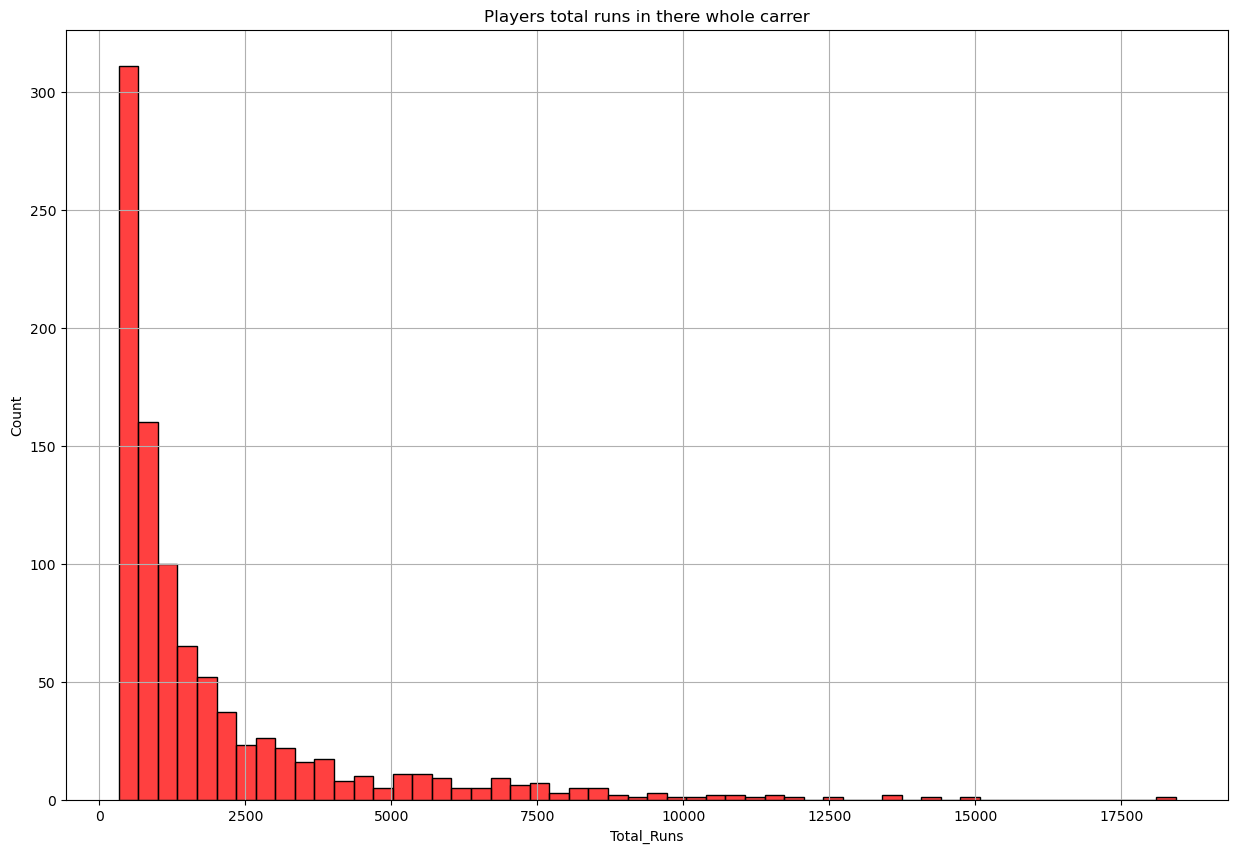

In [36]:
# Histogram(For Numerical)
plt.figure(figsize = (15,10))
sns.histplot(x = 'Total_Runs' , data = df,color='red')
plt.title('Players total runs in there whole carrer')
plt.grid()
plt.show()


# Observation:
This histogram shows the distribution of total career runs scored by all players.Most players have scored around 1,000 runs in their careers. Only a few players have scored very high runs up to 18,500 ,which appear as outliers.This indicates that while most players have relatively lower career runs, only a few have achieved outstanding batting records.

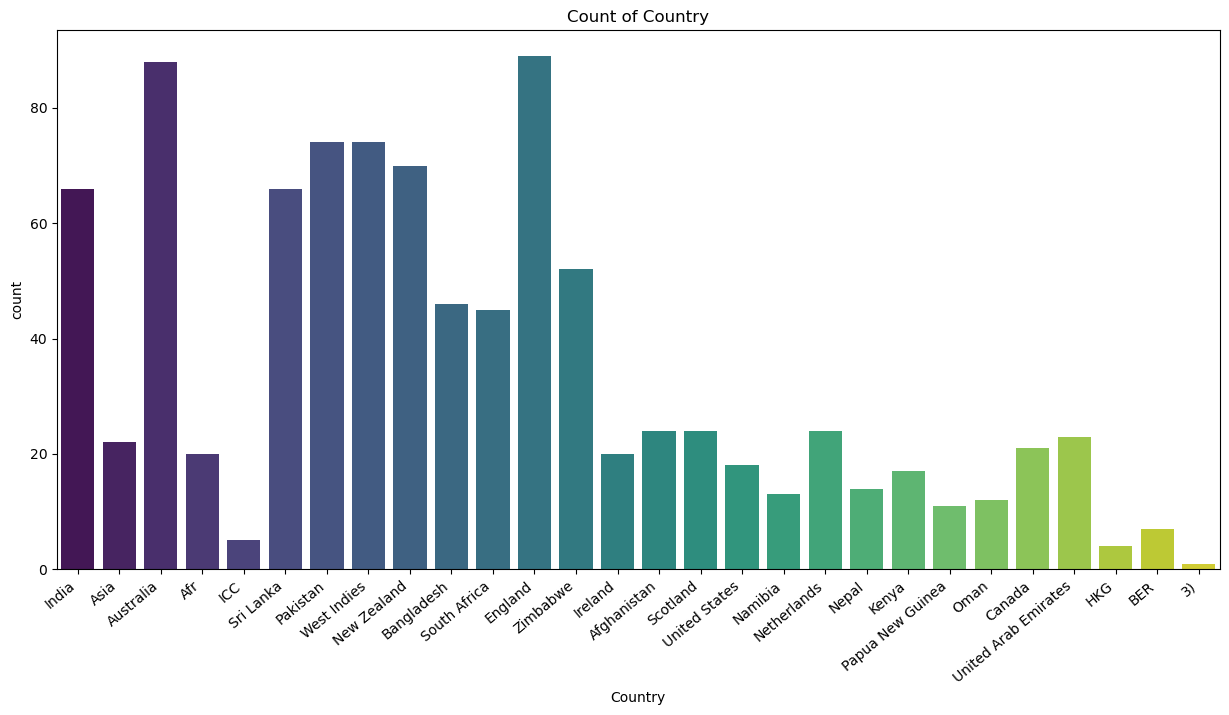

In [37]:
# For Count (Categorical Columns)
plt.figure(figsize=(15, 7))
# x specifies a vertical bar chart
sns.countplot(x='Country', data=df, palette='viridis') 
plt.xticks(rotation=40, ha='right')
plt.title('Count of Country')
plt.show()

# Observation:
This count plot shows the number of players from each country in the dataset. England has the highest number of players, followed by Australia and India. On the other hand, many countries have fewer players. This shows that the dataset includes more player records from a few major cricket-playing countries than from the others.

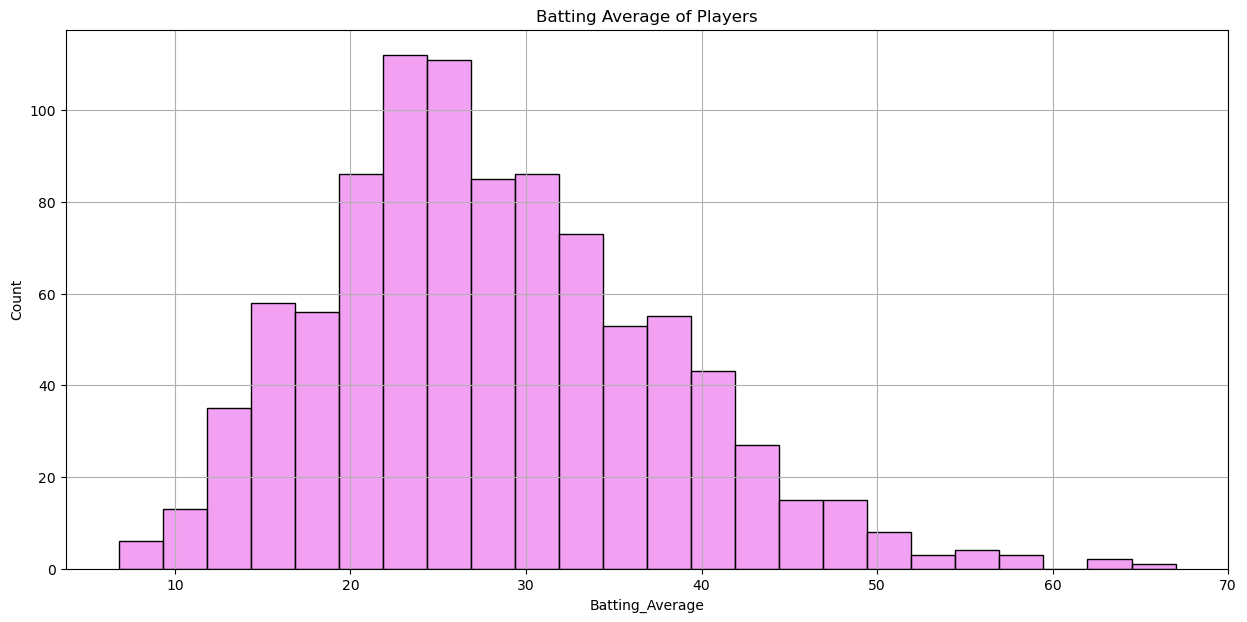

In [38]:
# For Histogram(Nume)
plt.figure(figsize = (15,7))
sns.histplot(x = 'Batting_Average' , data = df,color='violet')
plt.title('Batting Average of Players')
plt.grid()
plt.show()

# Observation:
This is the distribution of the Batting Average column. More than 100 players have a batting average between 20 and 25, showing that most players fall in this range. A few players have batting averages between 60 and 70, making them outliers in the dataset.

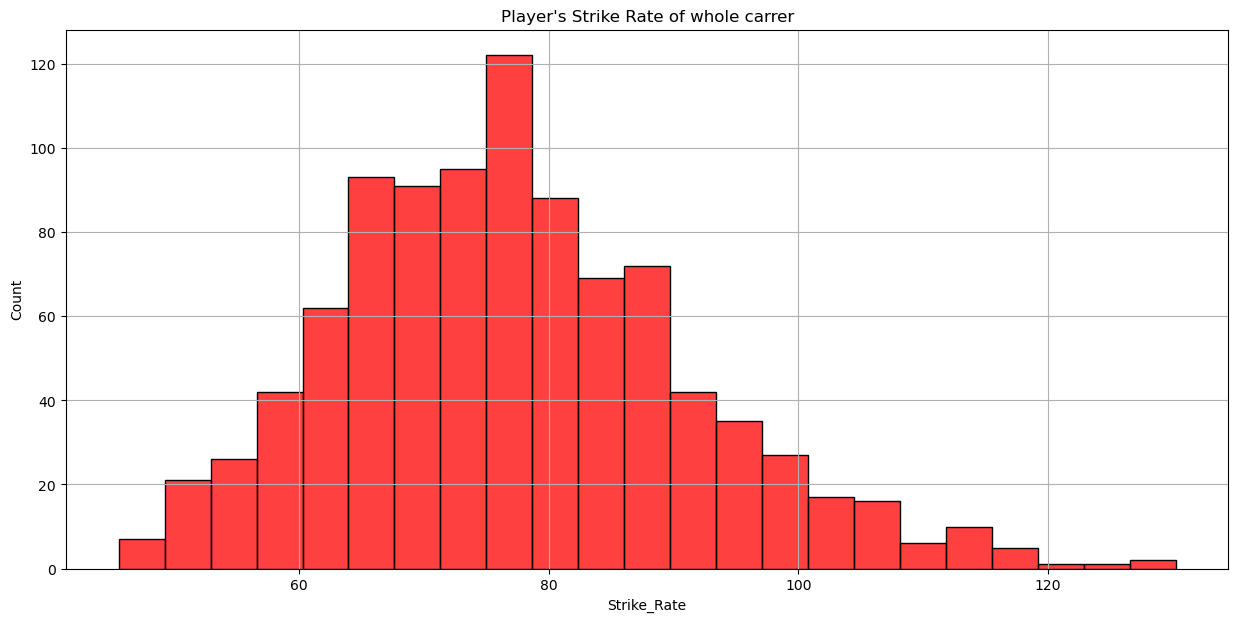

In [39]:
# Histogram(For Numerical)
plt.figure(figsize = (15,7))
sns.histplot(x = 'Strike_Rate' , data = df,color='red')
plt.title("Player's Strike Rate of whole carrer")
plt.grid()
plt.show()

# Observation:
This is the Distribution of Strike Rate Column.This graph displays the distribution of player strike rates. We can see that the most common strike rate is between 75 and 80, with over 120 players in this group. There is also a small number of players who have a strike rate above 120, which is an exceptional performance compared to the rest of the group.

# Bi-Variate Analysis

## 1.Numerical VS Numerical

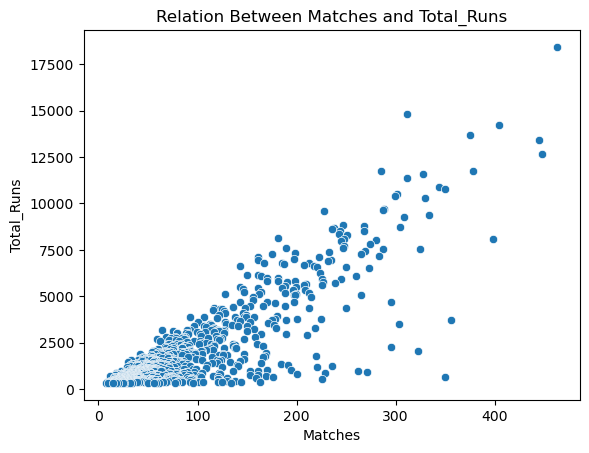

In [40]:
sns.scatterplot(x='Matches',y='Total_Runs',data=df)
plt.title('Relation Between Matches and Total_Runs')
plt.show() 

# Observation:
This scatter plot shows a positive relationship between Matches and Total Runs. Most players have played fewer than 150 matches and scored less than 5,000 runs. A few players have played more than 400 matches and scored over 18,000 runs, showing their outstanding batting records.

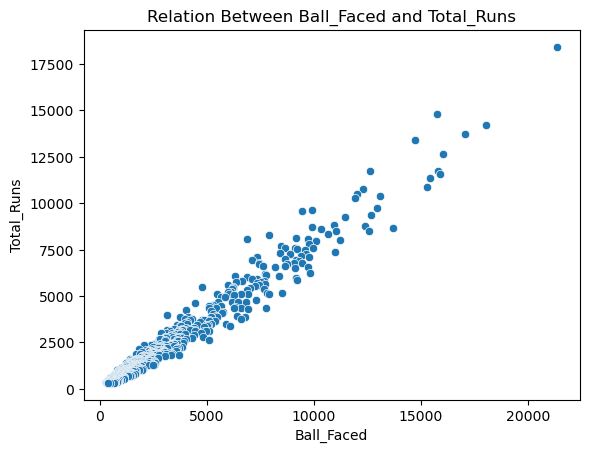

In [41]:
sns.scatterplot(x='Ball_Faced',y='Total_Runs',data=df)
plt.title('Relation Between Ball_Faced and Total_Runs')
plt.show()

# Observation:
This scatter plot shows a positive relationship between Balls Faced and Total Runs. Most players have faced fewer than 5,000 balls and scored less than 4,000 runs. A few players have faced over 21,000 balls and scored more than 18,000 runs, showing exceptional batting performance.

## Categorical VS Numerical

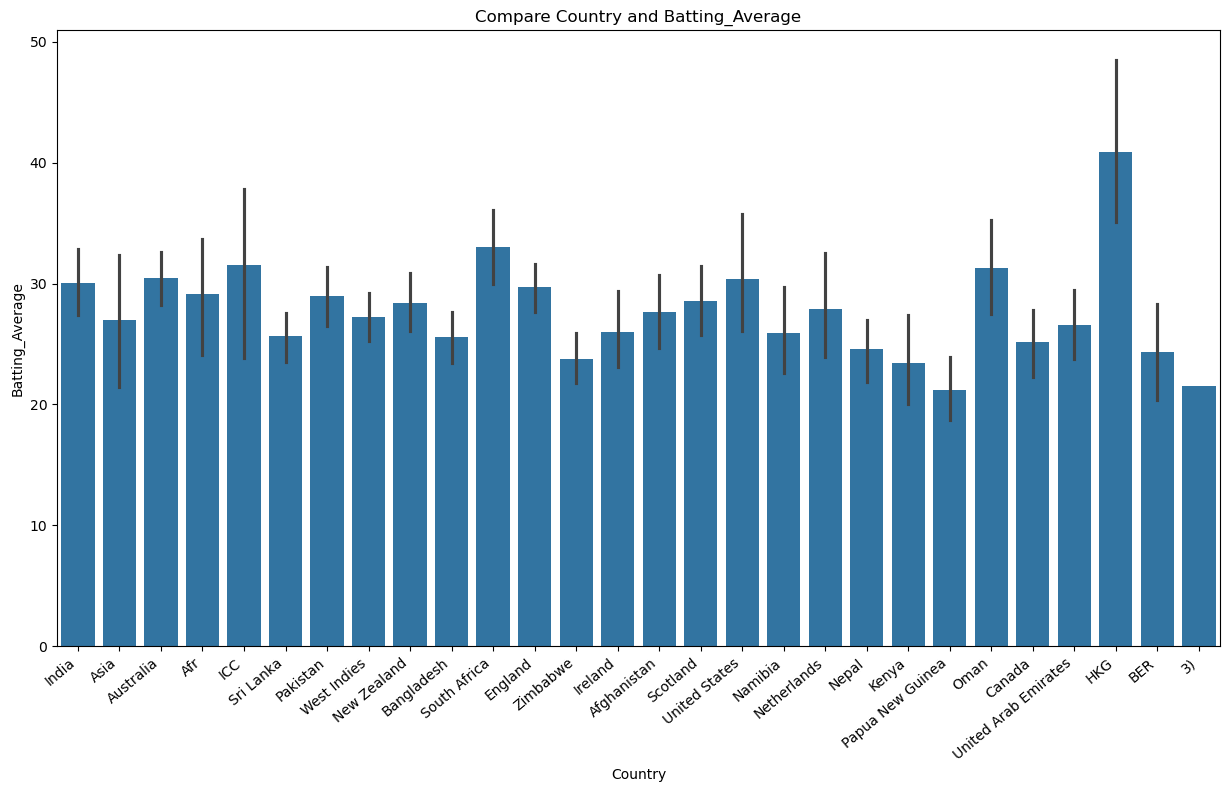

In [42]:
plt.figure(figsize = (15,8))
sns.barplot(x='Country', y='Batting_Average', data=df)
plt.xticks(rotation=40, ha='right')
plt.title('Compare Country and Batting_Average')
plt.show() 

# Observation:
This bar chart compares the average batting average across different countries. Most countries maintain a batting average between 25 and 35. The biggest standout is "HKG" (Hong Kong), which shows the highest average 40.Major cricketing nations like South Africa, Australia, and India consistently perform well, with averages above 30, while teams like Papua New Guinea, Kenya, and "BER" (Bermuda) have the lowest averages, sitting closer to 20.

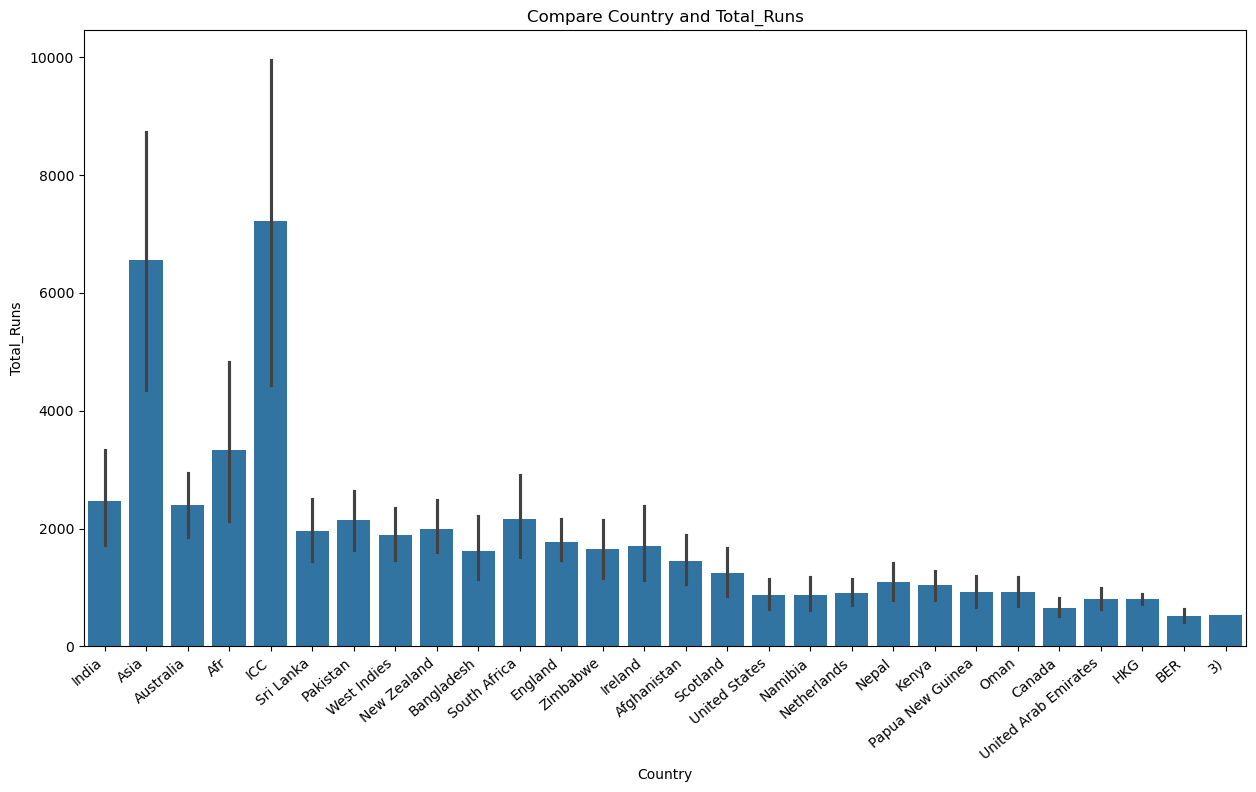

In [43]:
plt.figure(figsize = (15,8))
sns.barplot(x='Country', y='Total_Runs', data=df)
plt.xticks(rotation=40, ha='right')
plt.title('Compare Country and Total_Runs')
plt.show()

# Observation:
This bar chart compares the average total runs across different countries. ICC has the highest average total runs at around 7,200, followed by Asia with around 6,500 runs. Most other countries have average total runs between 1,000 and 2,500. On the other hand, Bermuda (BER), the United Arab Emirates, and the last category have the lowest average total runs, with values below 1,000.

# Multi-Variate Analysis

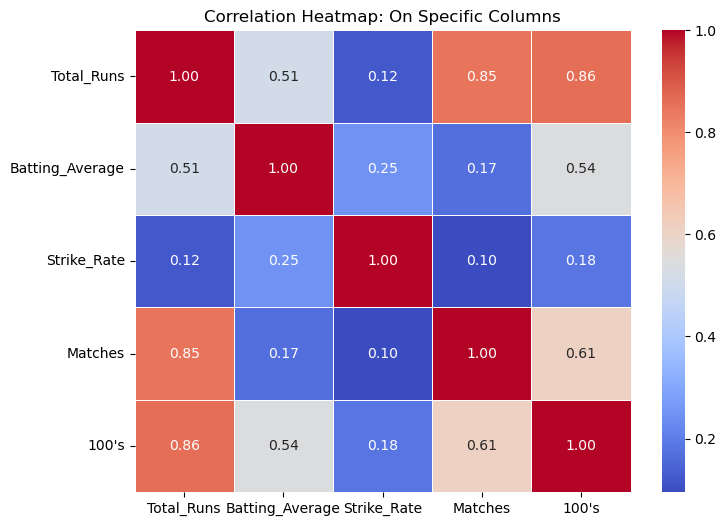

In [44]:
# Select the specific columns for the heatmap
cols_to_plot = ["Total_Runs", "Batting_Average", "Strike_Rate", "Matches", "100's"]
# Calculate the correlation matrix
correlation_matrix = df[cols_to_plot].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True,        # Show the correlation values
    cmap='coolwarm',   # Red-Blue color scheme
    fmt=".2f",         # Format to 2 decimal places
    linewidths=0.5
)
 
plt.title('Correlation Heatmap: On Specific Columns')
plt.show()

# Observation:
- This correlation heatmap shows the relationship between the selected batting statistics.
- Dark red colors represent a strong positive correlation, while blue colors represent a weak correlation.
- >- Total Runs has a strong positive correlation with 100's (0.86) and Matches (0.85), indicating that players who play more matches and score more centuries usually have higher total runs.
  >- Batting Average has a moderate correlation with Total Runs (0.51) and 100's (0.54).
  >- On the other hand, Strike Rate has a weak correlation with the other variables, with values ranging from 0.10 to 0.25, as shown by the blue shades.